In [39]:
from sklearn.model_selection import train_test_split, StratifiedKFold
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Imports
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [24]:
df = pd.read_csv('train.csv', low_memory=False)
df['year_index'] = pd.Series(df['academicYear']).rank(method='dense').astype(int)

# Set academicYear as index if needed
df.set_index('year_index', inplace=True)

# # Display the DataFrame
# print("DataFrame with year index:")
# print(df.head())
print(df.columns)

Index(['academicYear', 'idOSYM', 'scholarshipRate', 'quota', 'occupiedSlots',
       'tuitionFee', 'universityLocation', 'universityRegion', 'profCount',
       'assoCount', 'docCount', 'baseRanking', 'topRanking',
       'avgAdmissionRanking(TYT)', 'baseAdmissionRanking(TYT)',
       'stdDeviationStudents', 'revenue', 'outOfCityStudentRate',
       'totalPreference', 'top1PreferenceRatio', 'avgOrderofPreference',
       'avgAdmittedStudentPrefOrder', 'top1AdmittedRatio', 'top3AdmittedRatio',
       'top10AdmittedRatio', 'admittedTotalPref',
       'admittedTotalDepartmentPref', 'currentStudentCount', 'baseScore',
       'topScore', 'totalForeignStudents', 'totalStudentNumber', 'Urap_Rank',
       'Urap_Score', 'avg_monthly_income_group', 'Time_for_employment',
       'employment_rate', 'base_salary_by_year', 'inflation_by_year',
       'growth_by_year', 'universityType_devlet', 'universityType_vakıf',
       'programType_DİL', 'programType_EA', 'programType_SAY',
       'programType_S

In [25]:
df['lag_baseRanking'] = df.groupby(['universityName_encoded', 'departmentName_encoded', 'scholarshipRate'])['baseRanking'].shift(1)
print(df.isnull().sum())

academicYear                 0
idOSYM                       0
scholarshipRate              0
quota                        0
occupiedSlots                0
                          ... 
language_İtalyanca           0
universityName_encoded       0
departmentName_encoded       0
facultyName_encoded          0
lag_baseRanking           9925
Length: 63, dtype: int64


In [26]:
df.fillna(0, inplace=True)

In [27]:
x_2019 = df.loc[1].drop('baseRanking', axis=1)
y_2019 = df.loc[1]['baseRanking']

x_2020 = df.loc[2].drop('baseRanking', axis=1)
y_2020 = df.loc[2]['baseRanking']

x_2021 = df.loc[3].drop('baseRanking', axis=1)
y_2021 = df.loc[3]['baseRanking']

x_2022 = df.loc[4].drop('baseRanking', axis=1)
y_2022 = df.loc[4]['baseRanking']

x_2023 = df.loc[5].drop('baseRanking', axis=1)
y_2023 = df.loc[5]['baseRanking']

x_2024 = df.loc[6].drop('baseRanking', axis=1)
y_2024 = df.loc[6]['baseRanking']

In [28]:


# Function to plot predictions vs. actual values
def plot_predictions(y_true, y_pred, model_name):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Predictions vs. Actual Values ({model_name})')
    plt.grid(True)
    plt.show()

# Function to plot residuals
def plot_residuals(y_true, y_pred, model_name):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residuals Plot ({model_name})')
    plt.grid(True)
    plt.show()

# Function to plot model performance metrics
def plot_model_performance(y_true, y_preds, model_names):
    metrics = {'Model': [], 'RMSE': [], 'MAE': [], 'R2': []}
    for y_pred, model_name in zip(y_preds, model_names):
        metrics['Model'].append(model_name)
        metrics['RMSE'].append(np.sqrt(mean_squared_error(y_true, y_pred)))
        metrics['MAE'].append(mean_absolute_error(y_true, y_pred))
        metrics['R2'].append(r2_score(y_true, y_pred))
    
    metrics_df = pd.DataFrame(metrics)
    metrics_df.set_index('Model', inplace=True)
    
    metrics_df.plot(kind='bar', figsize=(12, 8))
    plt.title('Model Performance Metrics')
    plt.ylabel('Score')
    plt.grid(True)
    plt.show()

def plot_r2_scores(y_true, y_preds, model_names):
    r2_scores = [r2_score(y_true, y_pred) for y_pred in y_preds]
    plt.figure(figsize=(12, 8))
    plt.bar(model_names, r2_scores, color='skyblue')
    plt.xlabel('Model')
    plt.ylabel('R2 Score')
    plt.title('R2 Scores of Different Models')
    plt.grid(True)
    plt.show()
# Function to plot line plot of predictions
def plot_predictions_line(y_true, y_preds, model_names):
    plt.figure(figsize=(12, 8))
    plt.plot(y_true, label='Actual Values', linestyle='--', marker='o')
    for y_pred, model_name in zip(y_preds, model_names):
        plt.plot(y_pred, label=f'Predicted Values ({model_name})', linestyle='--', marker='o')
    plt.xlabel('Index')
    plt.ylabel('Values')
    plt.title('Predictions Line Plot')
    plt.legend()
    plt.grid(True)
    plt.show()

def visualize_model_performance(metrics_df):
    # Plot RMSE
    plt.figure(figsize=(14, 7))
    plt.plot(metrics_df.index, metrics_df['RMSE'], marker='o', label='RMSE')
    plt.xlabel('Year')
    plt.ylabel('RMSE')
    plt.title('Model Performance: RMSE by Year')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot MAE
    plt.figure(figsize=(14, 7))
    plt.plot(metrics_df.index, metrics_df['MAE'], marker='o', label='MAE')
    plt.xlabel('Year')
    plt.ylabel('MAE')
    plt.title('Model Performance: MAE by Year')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot R2
    plt.figure(figsize=(14, 7))
    plt.plot(metrics_df.index, metrics_df['R2'], marker='o', label='R2')
    plt.xlabel('Year')
    plt.ylabel('R2')
    plt.title('Model Performance: R2 by Year')
    plt.grid(True)
    plt.legend()
    plt.show()

# Visualize model comparison using MAE
def visualize_model_comparison(metrics_df):
    plt.figure(figsize=(14, 7))
    for model in metrics_df['Model'].unique():
        model_data = metrics_df[metrics_df['Model'] == model]
        plt.plot(model_data['Year'], model_data['MAE'], marker='o', label=model)
    plt.xlabel('Year')
    plt.ylabel('MAE')
    plt.title('Model Performance: MAE Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()
# Combine metrics into a single DataFrame
def combine_metrics(*metrics_dicts):
    combined_metrics = []
    for model_name, metrics in metrics_dicts:
        for year, values in metrics.items():
            combined_metrics.append({
                'Model': model_name,
                'Year': year,
                'RMSE': values['RMSE'],
                'MAE': values['MAE'],
                'R2': values['R2']
            })
    return pd.DataFrame(combined_metrics)


# # Example usage
# plot_predictions(y_true, y_pred_model1, 'Model 1')
# plot_residuals(y_true, y_pred_model1, 'Model 1')
# plot_model_performance(y_true, [y_pred_model1, y_pred_model2], ['Model 1', 'Model 2'])
# plot_predictions_line(y_true, [y_pred_model1, y_pred_model2], ['Model 1', 'Model 2'])

In [29]:

print("Shape of x_2019:", x_2019.shape)
print("Shape of y_2019:", y_2019.shape)

print("Shape of x_2020:", x_2020.shape)
print("Shape of y_2020:", y_2020.shape)

print("Shape of x_2021:", x_2021.shape)
print("Shape of y_2021:", y_2021.shape)

print("Shape of x_2022:", x_2022.shape)
print("Shape of y_2022:", y_2022.shape)

print("Shape of x_2023:", x_2023.shape)
print("Shape of y_2023:", y_2023.shape)

print("Shape of x_2024:", x_2024.shape)
print("Shape of y_2024:", y_2024.shape)

Shape of x_2019: (9942, 62)
Shape of y_2019: (9942,)
Shape of x_2020: (12849, 62)
Shape of y_2020: (12849,)
Shape of x_2021: (13793, 62)
Shape of y_2021: (13793,)
Shape of x_2022: (9206, 62)
Shape of y_2022: (9206,)
Shape of x_2023: (9650, 62)
Shape of y_2023: (9650,)
Shape of x_2024: (9841, 62)
Shape of y_2024: (9841,)


In [30]:
def train(model_or_constructor, x_train, y_train, x_test, **kwargs):
    if callable(model_or_constructor):
        # If it's a constructor, instantiate the model
        model = model_or_constructor(**kwargs)
    else:
        # If it's an instantiated model, use it directly
        model = model_or_constructor

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    
    return  model, y_pred

In [31]:
def evaluate(y_test, y_pred):
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"Model Metrics:\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")
    return rmse, mae, r2

/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.800e+12, tolerance: 5.926e+10
  model = cd_fast.enet_coordinate_descent(
/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 21512.6093, MAE: 11478.6602, R^2: 0.9941
Year 2019 Metrics:
RMSE: 21512.6093, MAE: 11478.6602, R^2: 0.9941


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 13428821.5446, MAE: 114552.6213, R^2: -5106.3091
Year 2020 Metrics:
RMSE: 13428821.5446, MAE: 114552.6213, R^2: -5106.3091


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.929e+11, tolerance: 4.870e+10
  model = cd_fast.enet_coordinate_descent(
/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 10623.7791, MAE: 1326.1820, R^2: 0.9990
Year 2021 Metrics:
RMSE: 10623.7791, MAE: 1326.1820, R^2: 0.9990


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.029e+11, tolerance: 1.033e+11
  model = cd_fast.enet_coordinate_descent(
/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 10313.0759, MAE: 990.8259, R^2: 0.9993
Year 2022 Metrics:
RMSE: 10313.0759, MAE: 990.8259, R^2: 0.9993


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.071e+11, tolerance: 1.470e+11
  model = cd_fast.enet_coordinate_descent(
/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 135774.4958, MAE: 15122.8541, R^2: 0.8864
Year 2023 Metrics:
RMSE: 135774.4958, MAE: 15122.8541, R^2: 0.8864


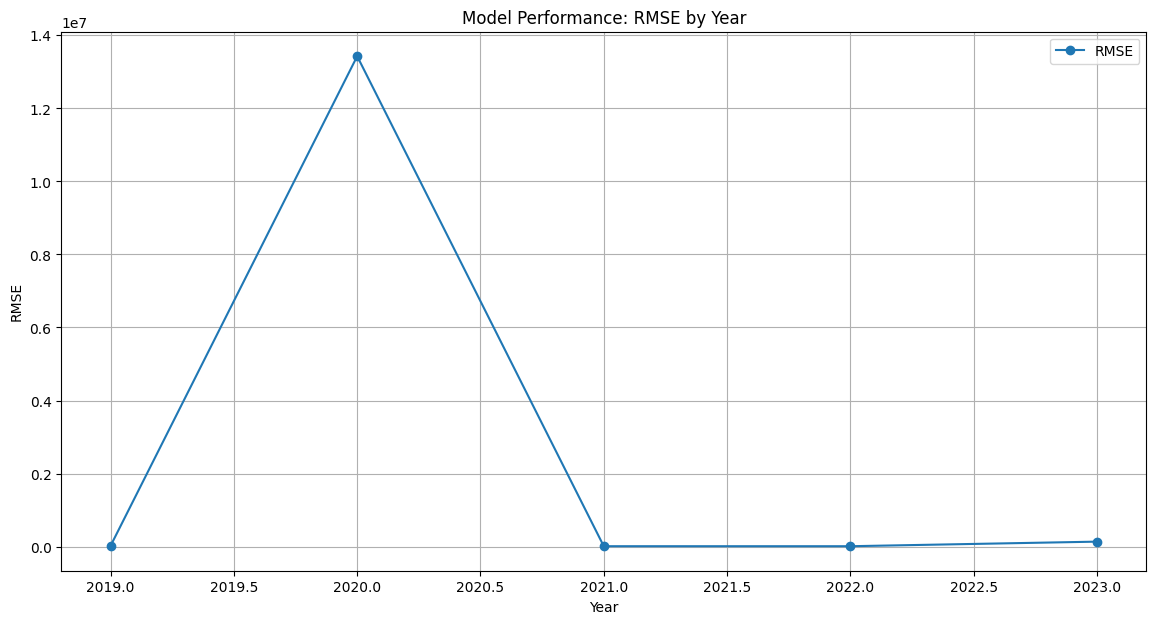

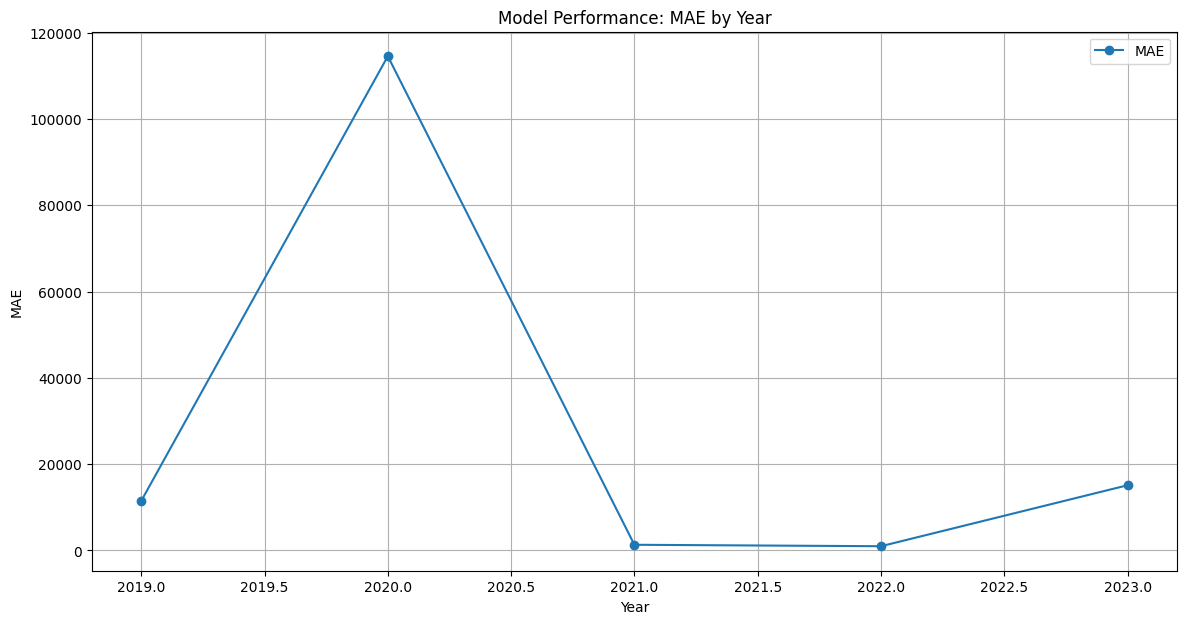

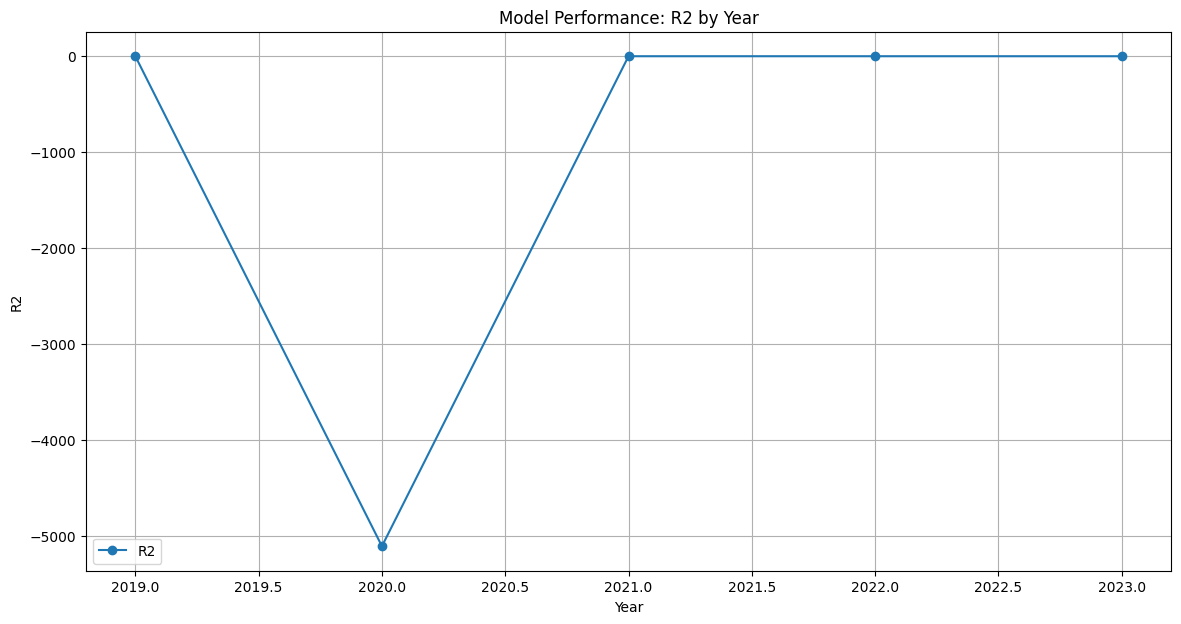

In [32]:
x_year = [x_2019, x_2020, x_2021, x_2022, x_2023, x_2024]
y_year = [y_2019, y_2020, y_2021, y_2022, y_2023, y_2024]

lasso_model = Lasso(alpha=0.1)
lasso_metrics = {}
lasso_model_year = {}
for i in range(1, len(x_year)):
    year = 2019+i-1
    lasso_model, pred = train(lasso_model, x_year[i-1], y_year[i-1], x_year[i])
    rmse, mae, r2 = evaluate(y_year[i], pred)
    lasso_metrics[year] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    lasso_model_year[year] = lasso_model
    
    print(f"Year {2019+i-1} Metrics:\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

metrics_df = pd.DataFrame(lasso_metrics).T
visualize_model_performance(metrics_df)

/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 67101.0678, MAE: 30439.0627, R^2: 0.9423
Year 2019 Metrics:
RMSE: 67101.0678, MAE: 30439.0627, R^2: 0.9423


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 54597.0583, MAE: 24722.3186, R^2: 0.9156
Year 2020 Metrics:
RMSE: 54597.0583, MAE: 24722.3186, R^2: 0.9156


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 205571.5483, MAE: 90253.9088, R^2: 0.6235
Year 2021 Metrics:
RMSE: 205571.5483, MAE: 90253.9088, R^2: 0.6235


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 28471.7475, MAE: 15117.8552, R^2: 0.9947
Year 2022 Metrics:
RMSE: 28471.7475, MAE: 15117.8552, R^2: 0.9947
Model Metrics:
RMSE: 70042.7593, MAE: 42457.2885, R^2: 0.9698
Year 2023 Metrics:
RMSE: 70042.7593, MAE: 42457.2885, R^2: 0.9698


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


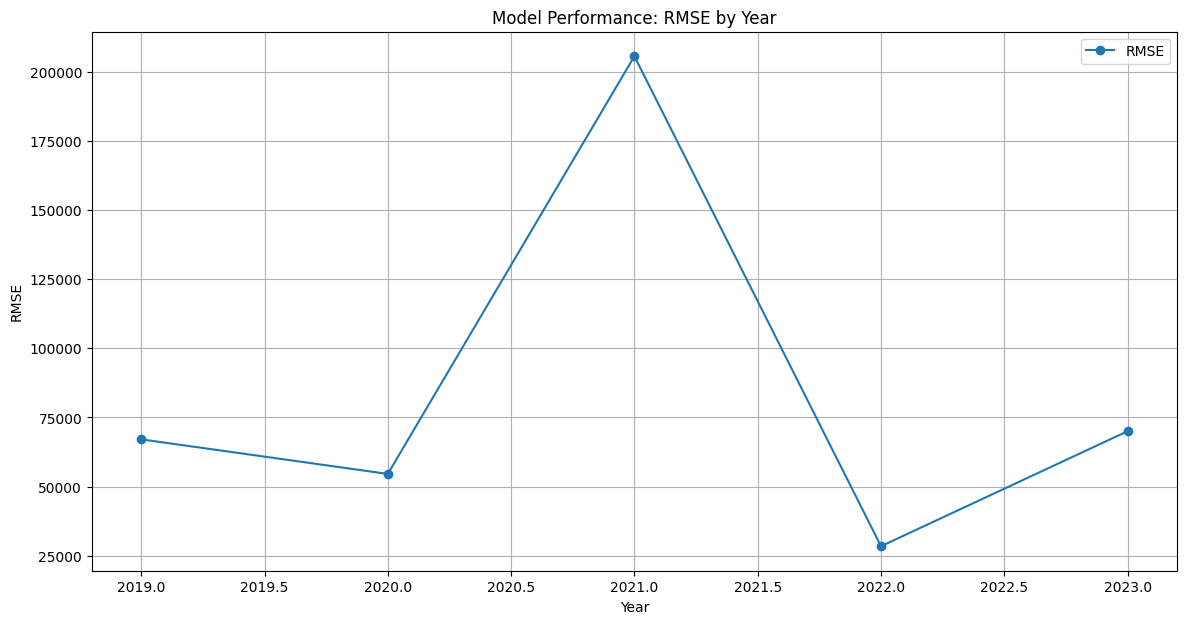

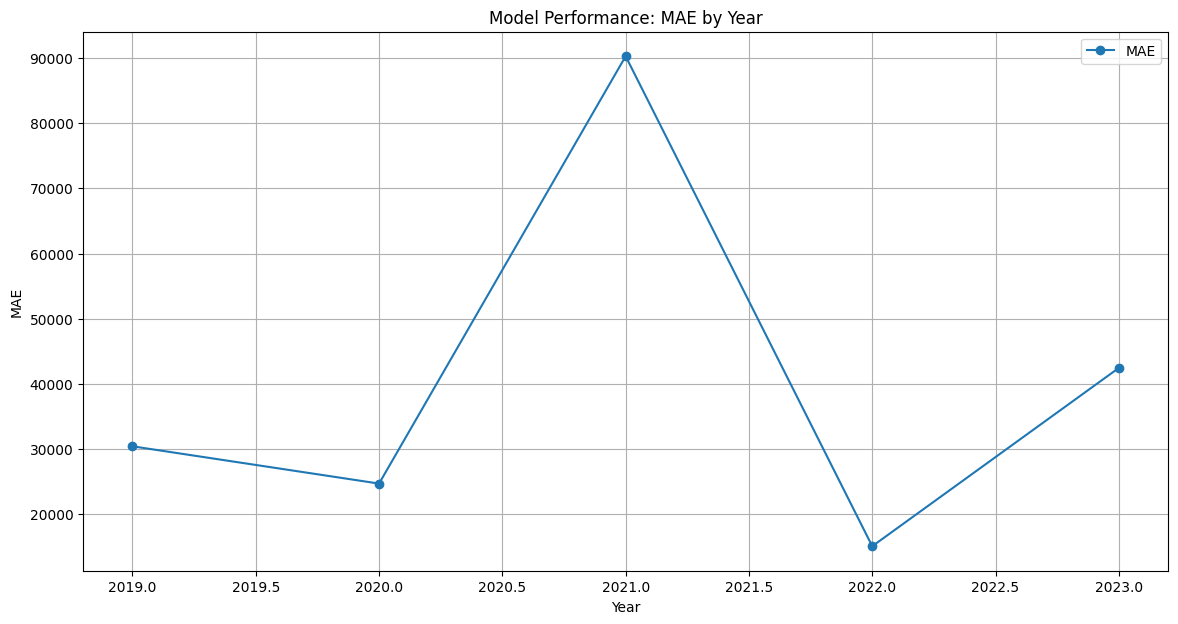

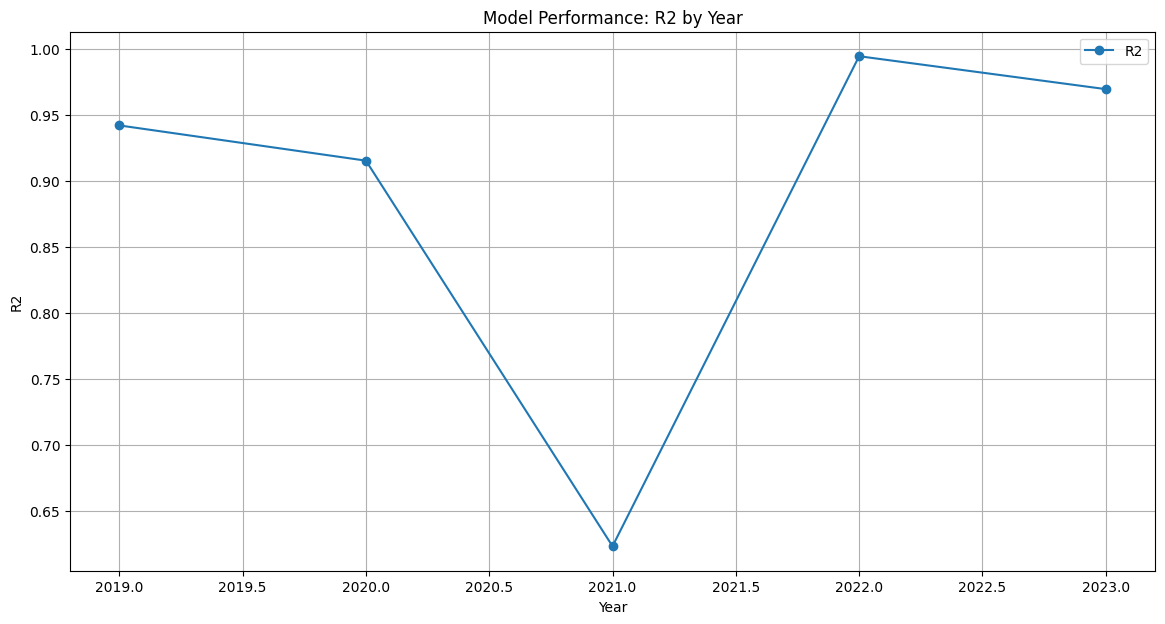

In [33]:
random_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_metrics = {}
random_model_year = {}

for i in range(1, len(x_year)):
    year = 2019+i-1
    random_model, pred = train(random_model, x_year[i-1], y_year[i-1], x_year[i])
    rmse, mae, r2 = evaluate(y_year[i], pred)
    random_metrics[year] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    random_model_year[year] = random_model
    
    print(f"Year {2019+i-1} Metrics:\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

metrics_df_random = pd.DataFrame(random_metrics).T
visualize_model_performance(metrics_df_random)

/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 50159.3889, MAE: 26475.4911, R^2: 0.9677
Year 2019 Metrics:
RMSE: 50159.3889, MAE: 26475.4911, R^2: 0.9677


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 33713.8535, MAE: 18763.3869, R^2: 0.9678
Year 2020 Metrics:
RMSE: 33713.8535, MAE: 18763.3869, R^2: 0.9678


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 270674.3967, MAE: 111280.8995, R^2: 0.3473
Year 2021 Metrics:
RMSE: 270674.3967, MAE: 111280.8995, R^2: 0.3473


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 29406.4420, MAE: 16700.9504, R^2: 0.9943
Year 2022 Metrics:
RMSE: 29406.4420, MAE: 16700.9504, R^2: 0.9943
Model Metrics:
RMSE: 63284.1032, MAE: 38083.8342, R^2: 0.9753
Year 2023 Metrics:
RMSE: 63284.1032, MAE: 38083.8342, R^2: 0.9753


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


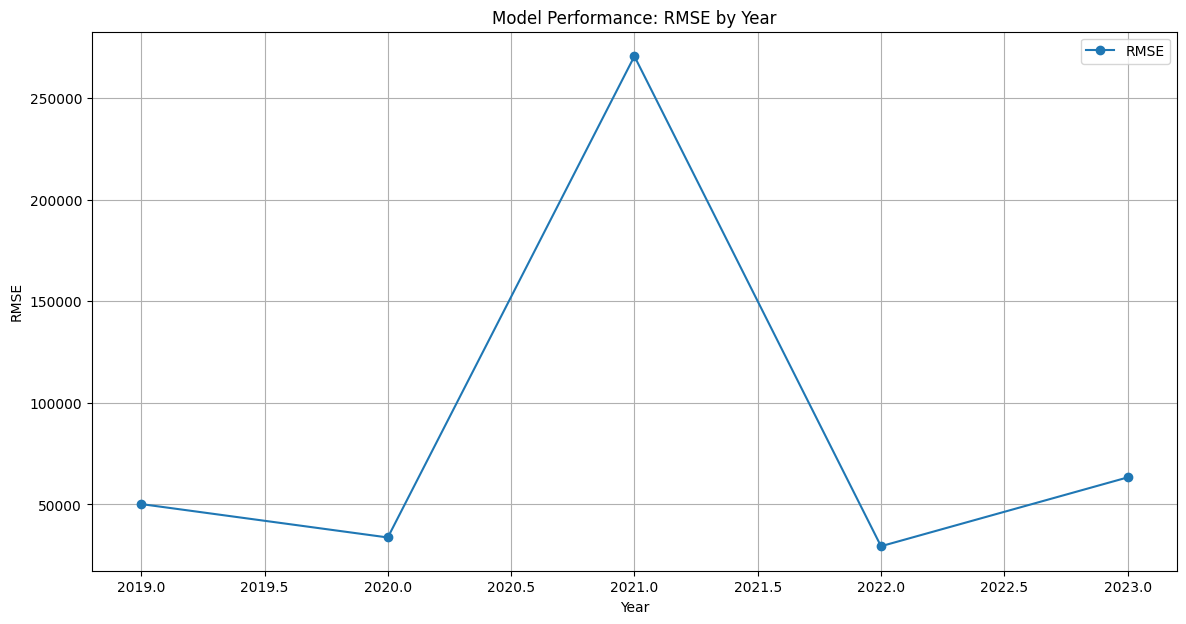

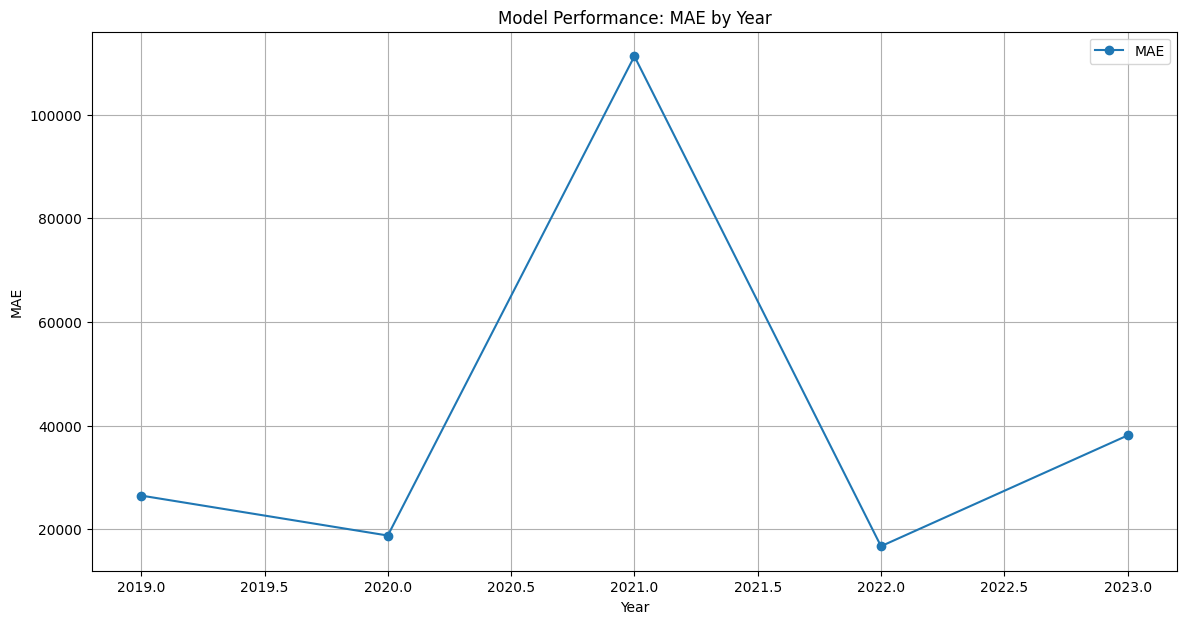

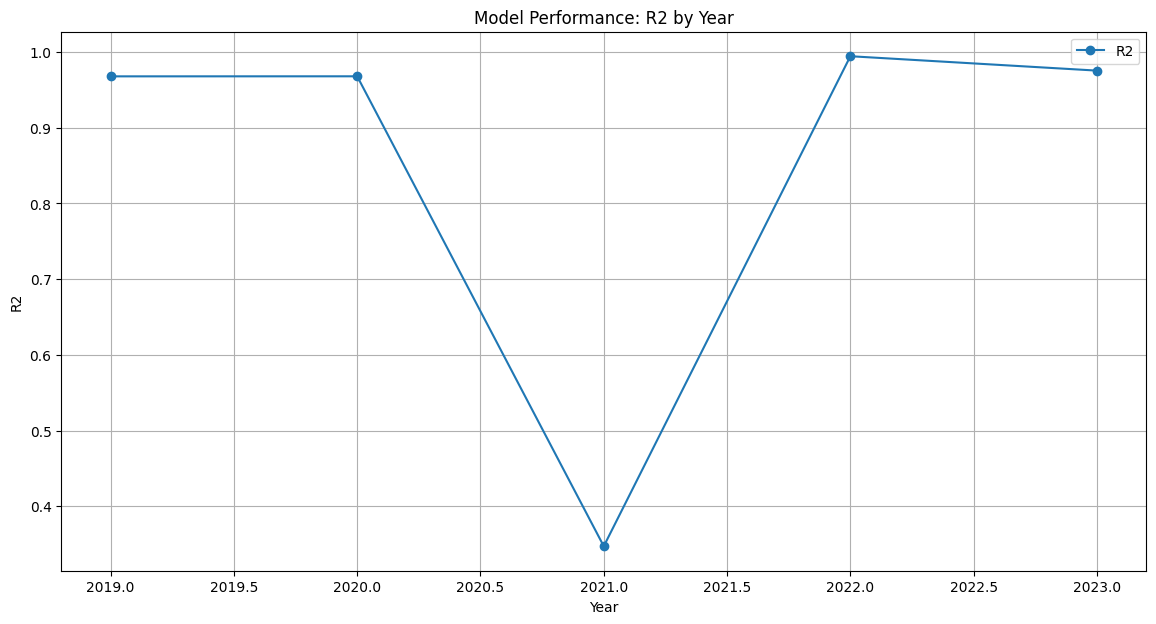

In [34]:
gradient_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gradient_metrics = {}
gradient_model_year = {}

for i in range(1, len(x_year)):
    year = 2019+i-1
    gradient_model, pred = train(gradient_model, x_year[i-1], y_year[i-1], x_year[i])
    rmse, mae, r2 = evaluate(y_year[i], pred)
    gradient_metrics[year] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    gradient_model_year[year] = gradient_model
    
    print(f"Year {2019+i-1} Metrics:\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

metrics_df_gradient = pd.DataFrame(gradient_metrics).T
visualize_model_performance(metrics_df_gradient)

/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 80350.5953, MAE: 38005.9773, R^2: 0.9172
Year 2019 Metrics:
RMSE: 80350.5953, MAE: 38005.9773, R^2: 0.9172


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 69127.3783, MAE: 31572.9174, R^2: 0.8647
Year 2020 Metrics:
RMSE: 69127.3783, MAE: 31572.9174, R^2: 0.8647


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 208368.7251, MAE: 94218.8451, R^2: 0.6132
Year 2021 Metrics:
RMSE: 208368.7251, MAE: 94218.8451, R^2: 0.6132


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 41373.4600, MAE: 18537.5119, R^2: 0.9888
Year 2022 Metrics:
RMSE: 41373.4600, MAE: 18537.5119, R^2: 0.9888
Model Metrics:
RMSE: 72502.1124, MAE: 43823.2148, R^2: 0.9676
Year 2023 Metrics:
RMSE: 72502.1124, MAE: 43823.2148, R^2: 0.9676


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


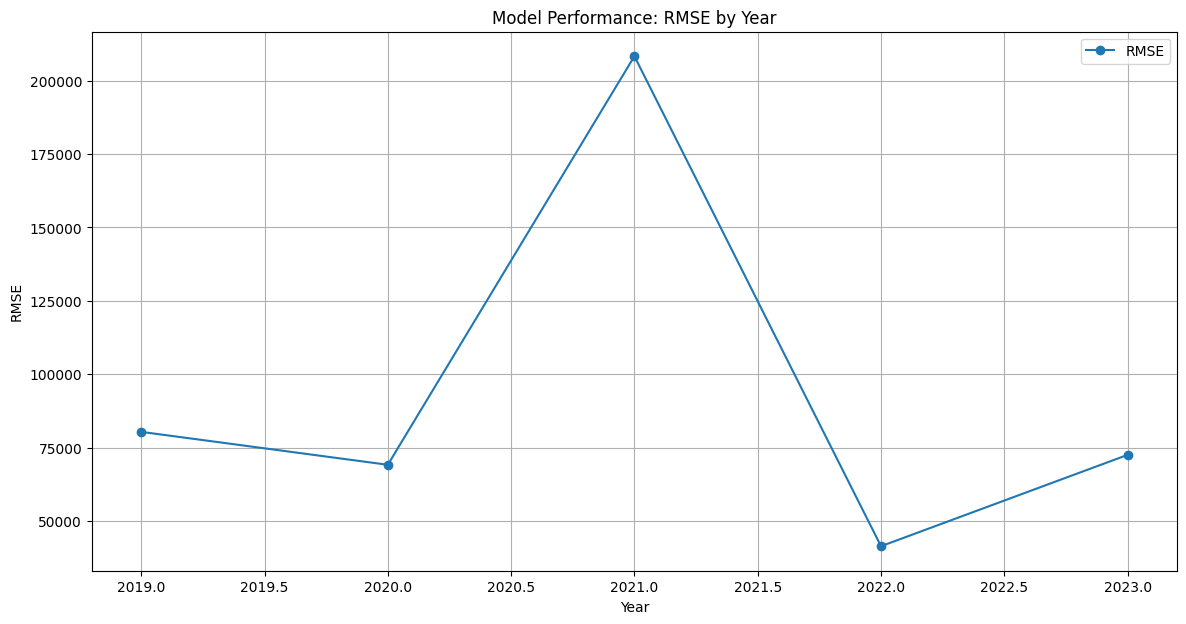

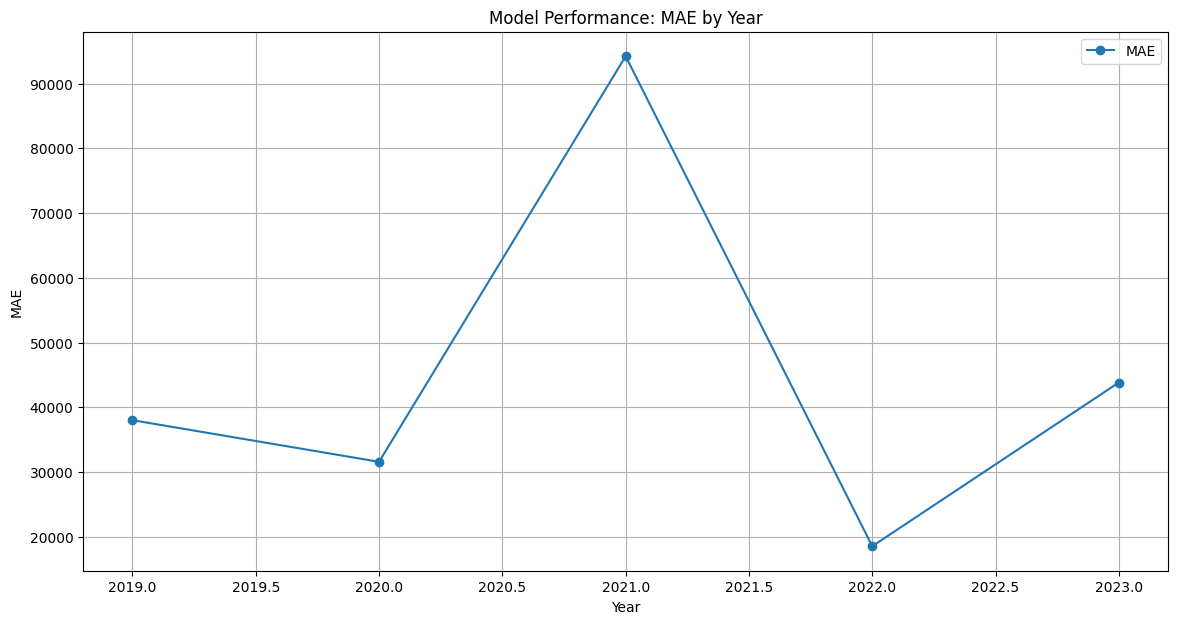

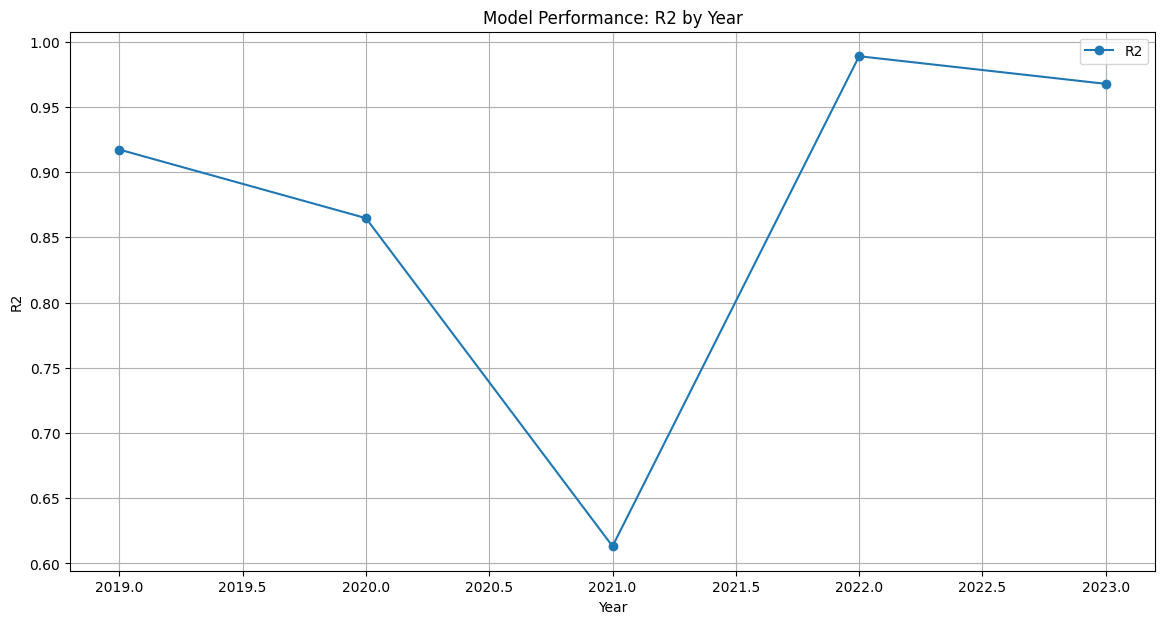

In [35]:
decision_model = DecisionTreeRegressor()
decision_metrics = {}
decision_model_year = {}

for i in range(1, len(x_year)):
    year = 2019+i-1
    decision_model, pred = train(decision_model, x_year[i-1], y_year[i-1], x_year[i])
    rmse, mae, r2 = evaluate(y_year[i], pred)
    decision_metrics[year] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    decision_model_year[year] = decision_model
    
    print(f"Year {2019+i-1} Metrics:\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

metrics_df_decision = pd.DataFrame(decision_metrics).T
visualize_model_performance(metrics_df_decision)


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 101820.0267, MAE: 64178.6113, R^2: 0.8671
Year 2019 Metrics:
RMSE: 101820.0267, MAE: 64178.6113, R^2: 0.8671


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 92192.2414, MAE: 57437.7134, R^2: 0.7593
Year 2020 Metrics:
RMSE: 92192.2414, MAE: 57437.7134, R^2: 0.7593


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 205044.9290, MAE: 102006.3427, R^2: 0.6255
Year 2021 Metrics:
RMSE: 205044.9290, MAE: 102006.3427, R^2: 0.6255


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 167984.1695, MAE: 80886.5169, R^2: 0.8147
Year 2022 Metrics:
RMSE: 167984.1695, MAE: 80886.5169, R^2: 0.8147


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 211446.2894, MAE: 131550.3395, R^2: 0.7244
Year 2023 Metrics:
RMSE: 211446.2894, MAE: 131550.3395, R^2: 0.7244


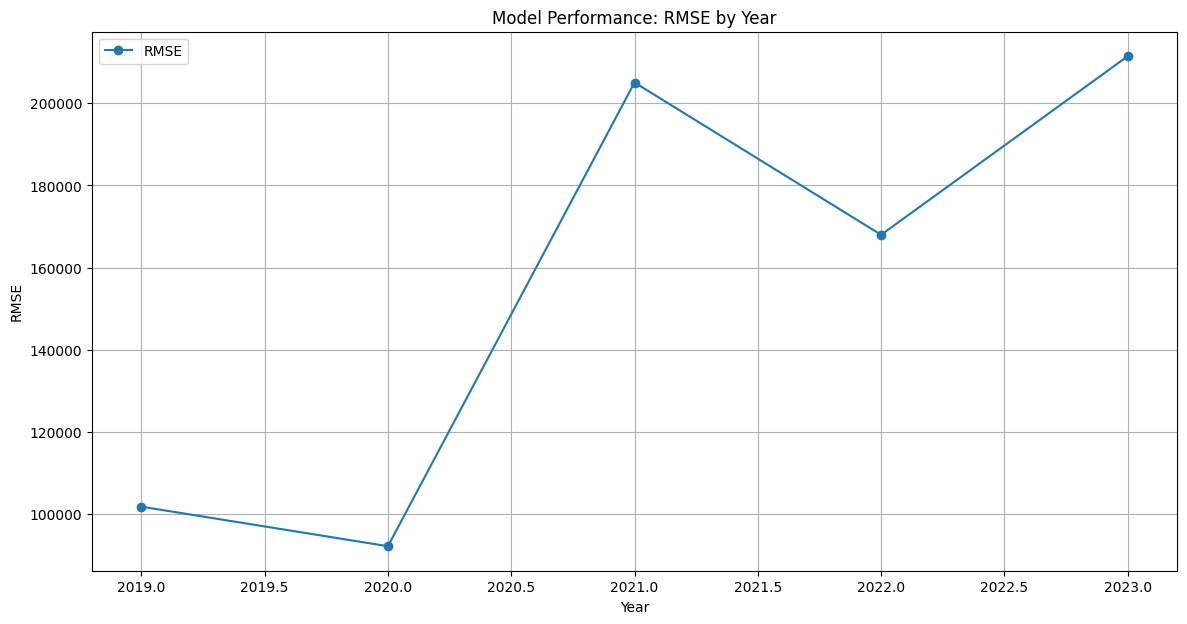

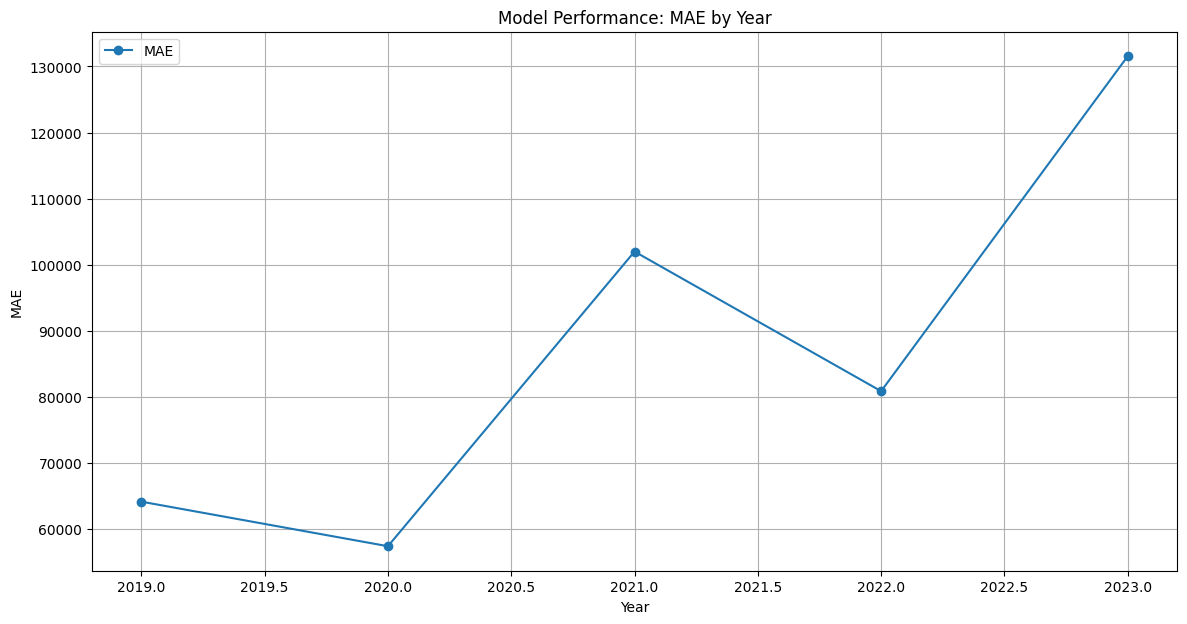

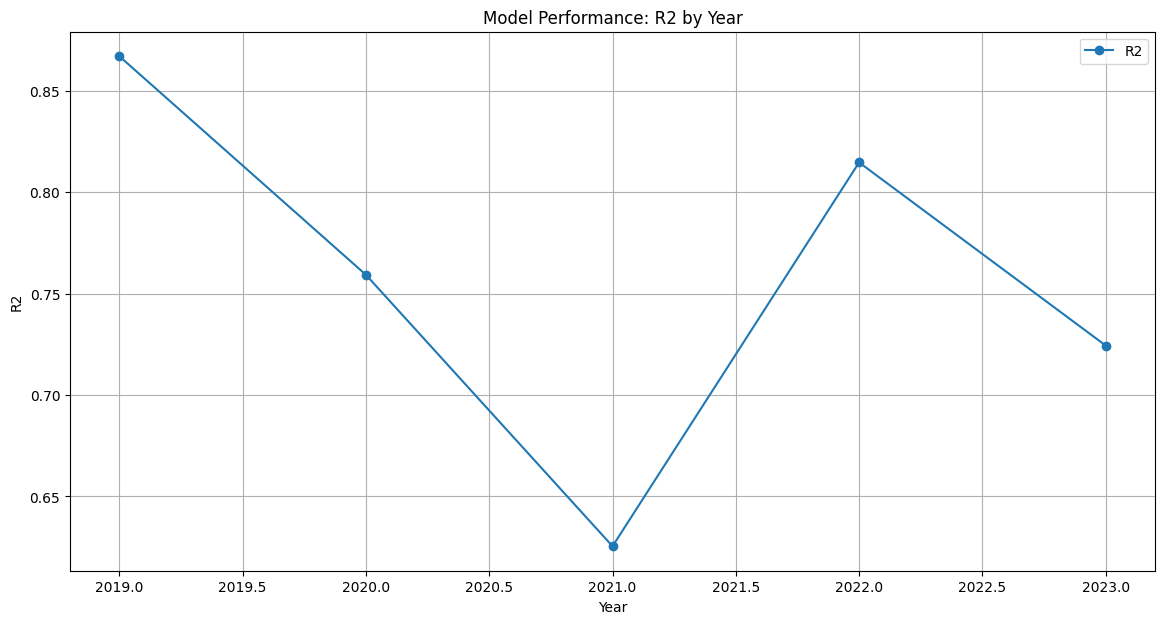

In [36]:
knn_model = KNeighborsRegressor()
knn_metrics = {}
knn_model_year = {}

for i in range(1, len(x_year)):
    year = 2019+i-1
    knn_model, pred = train(knn_model, x_year[i-1], y_year[i-1], x_year[i])
    rmse, mae, r2 = evaluate(y_year[i], pred)
    knn_metrics[year] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    knn_model_year[year] = knn_model
    
    print(f"Year {2019+i-1} Metrics:\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

metrics_df_knn = pd.DataFrame(knn_metrics).T
visualize_model_performance(metrics_df_knn)

/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.825e+12, tolerance: 5.926e+10
  model = cd_fast.enet_coordinate_descent(
/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 21673.1653, MAE: 11389.8900, R^2: 0.9940
Year 2019 Metrics:
RMSE: 21673.1653, MAE: 11389.8900, R^2: 0.9940


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 33295.9314, MAE: 449.3514, R^2: 0.9686
Year 2020 Metrics:
RMSE: 33295.9314, MAE: 449.3514, R^2: 0.9686


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 10606.6793, MAE: 1196.2685, R^2: 0.9990
Year 2021 Metrics:
RMSE: 10606.6793, MAE: 1196.2685, R^2: 0.9990


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.030e+11, tolerance: 1.033e+11
  model = cd_fast.enet_coordinate_descent(
/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 10307.4125, MAE: 927.3502, R^2: 0.9993
Year 2022 Metrics:
RMSE: 10307.4125, MAE: 927.3502, R^2: 0.9993


/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.074e+11, tolerance: 1.470e+11
  model = cd_fast.enet_coordinate_descent(
/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Model Metrics:
RMSE: 135750.6957, MAE: 15089.0338, R^2: 0.8864
Year 2023 Metrics:
RMSE: 135750.6957, MAE: 15089.0338, R^2: 0.8864


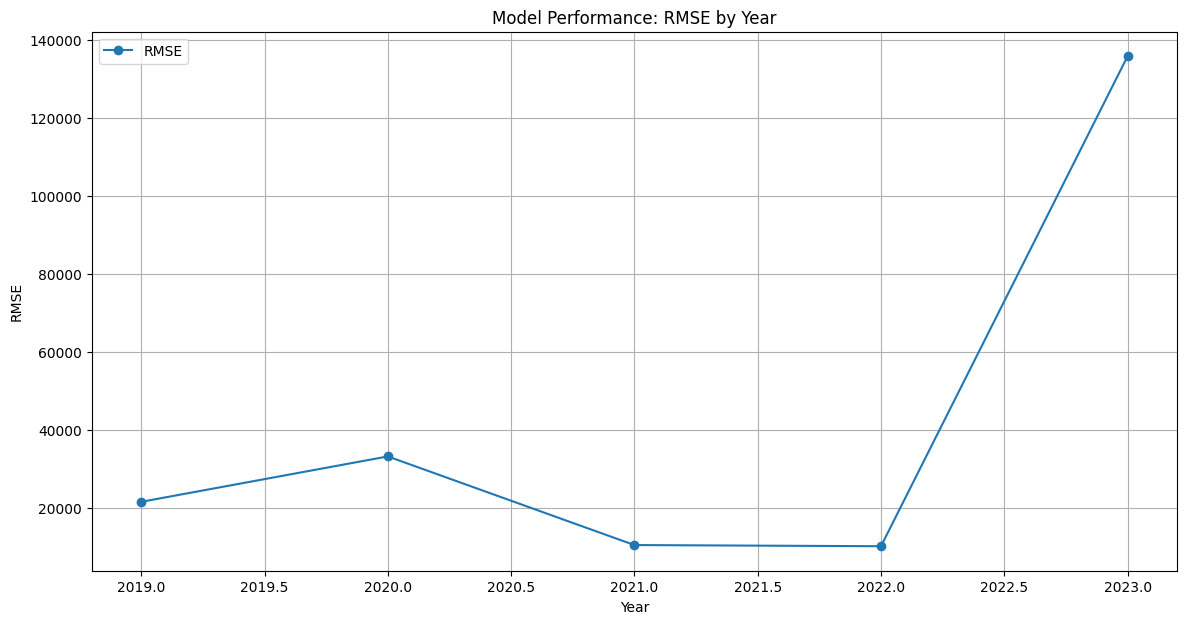

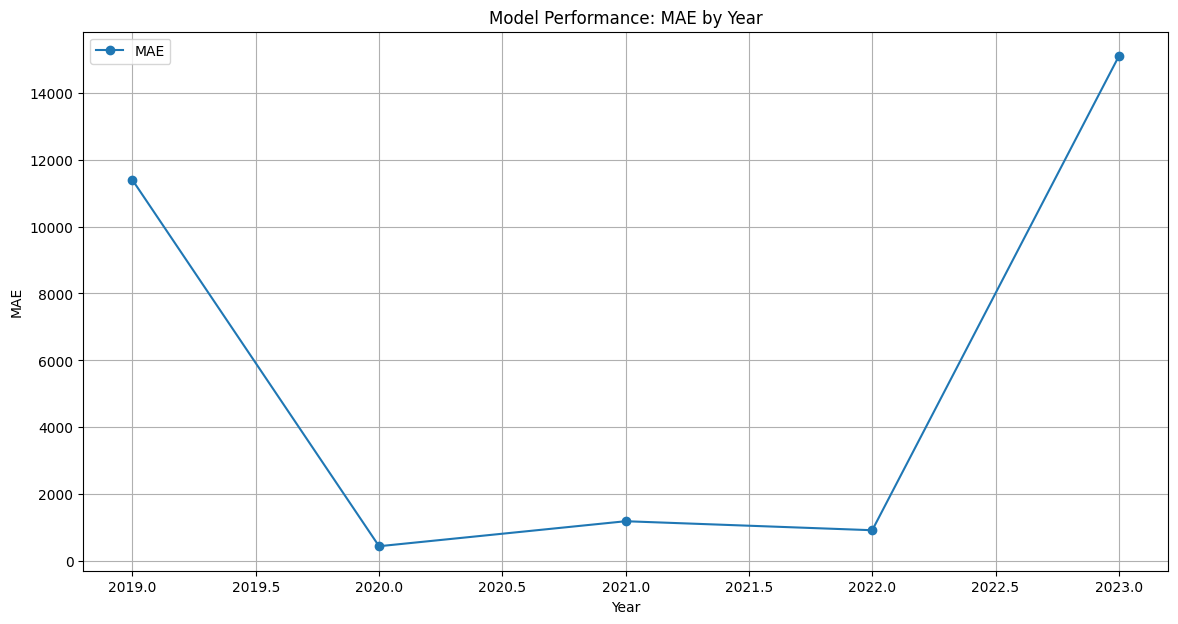

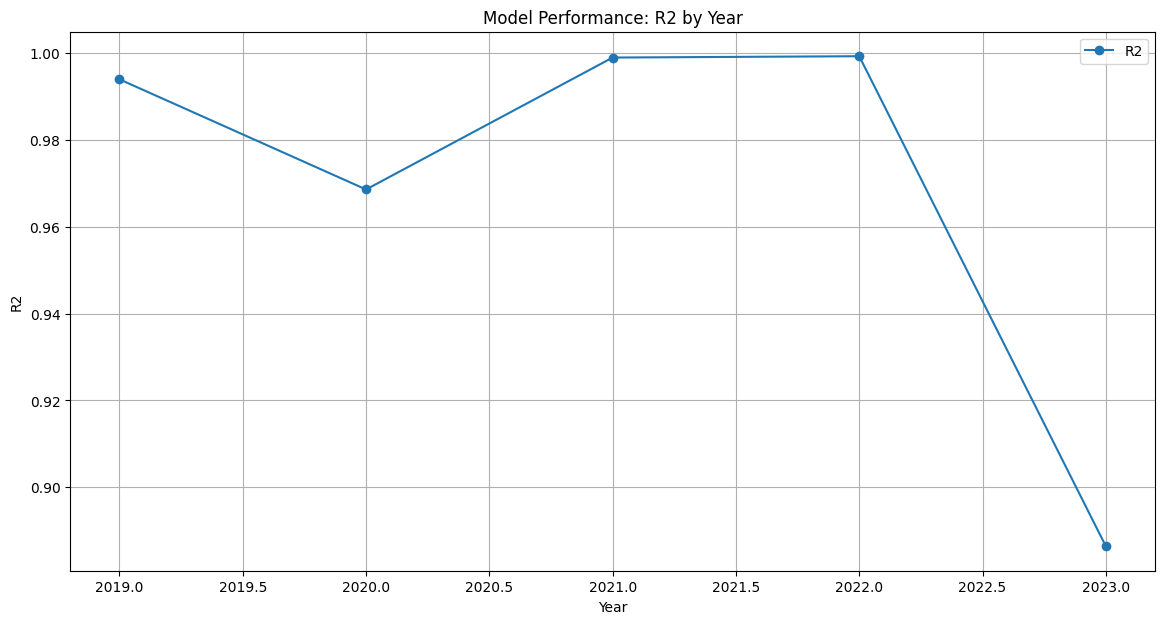

In [37]:
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_metrics = {}
elastic_model_year = {}

for i in range(1, len(x_year)):
    year = 2019+i-1
    elastic_model, pred = train(elastic_model, x_year[i-1], y_year[i-1], x_year[i])
    rmse, mae, r2 = evaluate(y_year[i], pred)
    elastic_metrics[year] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    elastic_model_year[year] = elastic_model
    
    print(f"Year {2019+i-1} Metrics:\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

metrics_df_elastic = pd.DataFrame(elastic_metrics).T
visualize_model_performance(metrics_df_elastic)


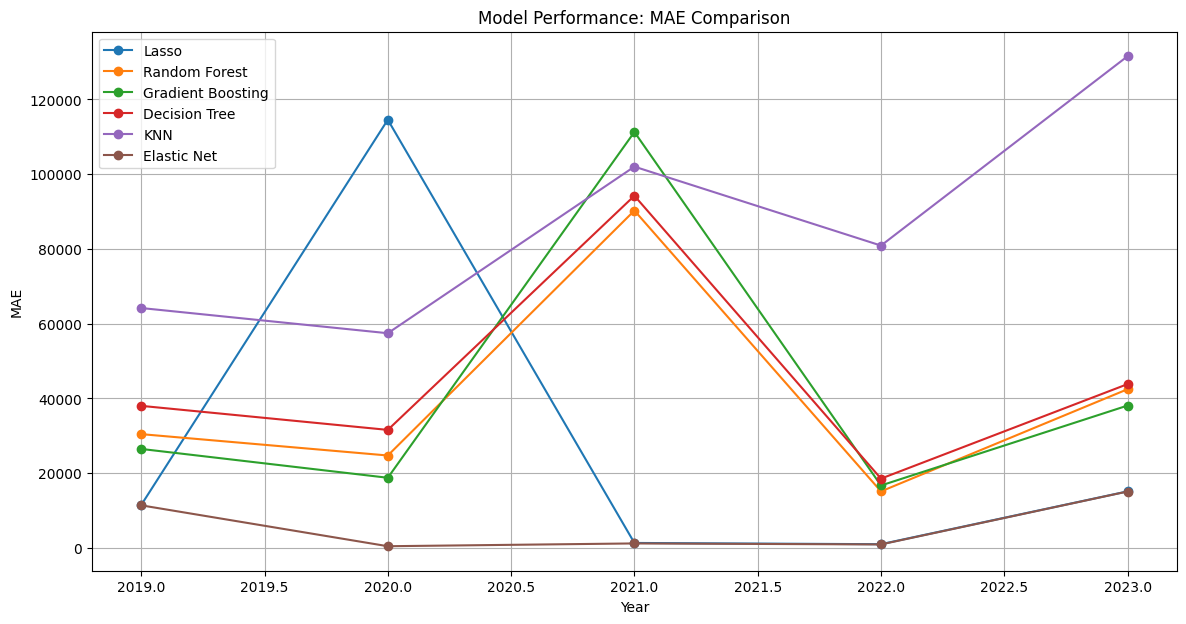

In [38]:
metrics_df_combined = combine_metrics(('Lasso', lasso_metrics), ('Random Forest', random_metrics), ('Gradient Boosting', gradient_metrics), ('Decision Tree', decision_metrics), ('KNN', knn_metrics), ('Elastic Net', elastic_metrics))
visualize_model_comparison(metrics_df_combined)

In [40]:
df['academicYear'] = pd.to_datetime(df['academicYear'])
print(df['academicYear'].dtype)

datetime64[ns]


In [41]:
class HybridModel:
    def __init__(self):
        # Prophet requires 'ds' (date) and 'y' (target) columns
        self.prophet = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            seasonality_mode='multiplicative'
        )
        
        self.rf_model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            random_state=42
        )
        
        self.linear_model = LinearRegression()
        
    def prepare_prophet_data(self, X, y=None):
        # Prophet requires specific column names
        prophet_df = pd.DataFrame()
        prophet_df['ds'] = pd.to_datetime(X['academicYear'].astype(str))
        if y is not None:
            prophet_df['y'] = y
        return prophet_df
    
    def fit(self, X, y):
        # Fit Prophet
        prophet_data = self.prepare_prophet_data(X, y)
        self.prophet.fit(prophet_data)
        
        # Get Prophet predictions for training
        prophet_preds = self.prophet.predict(prophet_data)['yhat']
        
        # Fit RF and Linear with remaining features
        features_for_other_models = X[numerical_features + categorical_features]
        
        self.rf_model.fit(features_for_other_models, y)
        self.linear_model.fit(X[numerical_features], y)
        
    def predict(self, X):
        # Get predictions from each model
        prophet_data = self.prepare_prophet_data(X)
        prophet_preds = self.prophet.predict(prophet_data)['yhat']
        
        rf_preds = self.rf_model.predict(X[numerical_features + categorical_features])
        linear_preds = self.linear_model.predict(X[numerical_features])
        
        # Combine predictions (simple average)
        final_predictions = (prophet_preds + rf_preds + linear_preds) / 3
        return final_predictions

# Usage example:
numerical_features = ['scholarshipRate', 'quota', 'baseScore', 'topScore', 
                     'profCount', 'assoCount', 'docCount', 'baseRanking']
categorical_features = ['universityType_devlet', 'universityType_vakıf', 
                       'programType_DİL', 'programType_EA']


In [42]:

model_hybrid = HybridModel()
for i in range(1, len(x_year)):
    year = 2019+i-1
    model_hybrid.fit(x_year[i-1], y_year[i-1])
    pred = model_hybrid.predict(x_year[i])
    rmse, mae, r2 = evaluate(y_year[i], pred)
    print(f"Year {2019+i-1} Metrics:\nRMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

20:15:16 - cmdstanpy - INFO - Chain [1] start processing
20:15:17 - cmdstanpy - INFO - Chain [1] done processing
20:15:17 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
20:15:17 - cmdstanpy - INFO - Chain [1] start processing
20:15:17 - cmdstanpy - INFO - Chain [1] done processing
20:15:17 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted


RuntimeError: Error during optimization! Command '/Users/omeryildiz/Documents/GitHub/WebScraping-Dataset-/.venv/lib/python3.12/site-packages/prophet/stan_model/prophet_model.bin random seed=13169 data file=/var/folders/lz/72v2qwyx34g0fk80lsqg3qt80000gn/T/tmpgk16xhb8/exex5a7r.json init=/var/folders/lz/72v2qwyx34g0fk80lsqg3qt80000gn/T/tmpgk16xhb8/e2p7suwq.json output file=/var/folders/lz/72v2qwyx34g0fk80lsqg3qt80000gn/T/tmpgk16xhb8/prophet_modelcxm3pxs5/prophet_model-20250105201517.csv method=optimize algorithm=newton iter=10000' failed: console log output:

method = optimize
  optimize
    algorithm = newton
      newton
    jacobian = 0 (Default)
    iter = 10000
    save_iterations = 0 (Default)
id = 1 (Default)
data
  file = /var/folders/lz/72v2qwyx34g0fk80lsqg3qt80000gn/T/tmpgk16xhb8/exex5a7r.json
init = /var/folders/lz/72v2qwyx34g0fk80lsqg3qt80000gn/T/tmpgk16xhb8/e2p7suwq.json
random
  seed = 13169
output
  file = /var/folders/lz/72v2qwyx34g0fk80lsqg3qt80000gn/T/tmpgk16xhb8/prophet